<a href="https://colab.research.google.com/github/nomin-hub/AIFFEL_quest_cr/blob/main/AIFFEL_quest_cr/NLP/NLP03/translator_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  영어 → 스페인어 번역기 프로젝트

---

## 목차

```
① 라이브러리 설치 & 임포트
        ↓
② 데이터 다운로드 & 전처리
        ↓
③ 데이터 증강 (GloVe Lexical Substitution - 따로 찾아봤습니다)
        ↓
④ 토크나이저 학습 (SentencePiece)
        ↓
⑤ DataLoader 구성
        ↓
⑥ Transformer 모델 구현
        ↓
⑦ 마스크 생성
        ↓
⑧ 학습 (20 epoch)
        ↓
⑨ 번역 & BLEU 평가
```

---
# STEP 1 — 라이브러리 설치 & 임포트

필요한 라이브러리를 먼저 설치.

- `gensim`: Word2Vec / GloVe 등 단어 임베딩 라이브러리 → 데이터 증강에 사용
- `sentencepiece`: 구글이 만든 서브워드 토크나이저 → 텍스트를 숫자로 변환
- `nltk`: 자연어 처리 도구 모음 → BLEU 점수 계산에 사용

In [ ]:
!pip install -q gensim sentencepiece nltk

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import re, os, random, math, urllib.request, zipfile
from tqdm.notebook import tqdm
from torch.utils.data import TensorDataset, DataLoader

print('PyTorch 버전:', torch.__version__)

# GPU가 있으면 GPU, 없으면 CPU 사용
# GPU를 쓰면 학습 속도가 수십 배 빨라집니다
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('학습 장치:', device)

PyTorch 버전: 2.10.0+cu128
학습 장치: cuda


---
# STEP 2 — 데이터 다운로드 & 전처리

## 2-1. 데이터셋 소개

**spa-eng 데이터셋** (출처: TensorFlow 공개 데이터)
- 영어 문장 + 스페인어 번역 쌍으로 구성
- 전체 약 11만 8천 쌍

## 2-2. 전처리 함수

**왜 전처리가 필요한가?**

모델은 텍스트를 직접 이해하지 못합니다. 숫자(토큰 ID)로 변환해야 하는데,
그 전에 텍스트를 깔끔하게 정리해야 토크나이저가 더 좋은 품질의 어휘를 만들 수 있습니다.

In [ ]:
# 데이터 다운로드 및 압축 해제
urllib.request.urlretrieve(
    'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip',
    'spa-eng.zip'
)
with zipfile.ZipFile('spa-eng.zip', 'r') as z:
    z.extractall('.')
print('다운로드 완료. 슝=3')

다운로드 완료. 슝=3


In [ ]:
def preprocess_sentence(sentence):
    """
    문장 전처리 함수

    처리 순서:
    1. 소문자 변환     : "Hello" → "hello"
    2. 특수문자 분리   : "hello." → "hello ."  ← ✅ 개선 포인트
    3. 중복 공백 제거  : "hello  world" → "hello world"
    4. 앞뒤 공백 제거  : " hello " → "hello"
    """
    sentence = sentence.lower()
    sentence = re.sub(r'([?.!,¿])', r' \1 ', sentence)  # 특수문자 앞뒤 공백
    sentence = re.sub(r' {2,}', ' ', sentence)           # 중복 공백 → 단일 공백
    return sentence.strip()

# 전처리 결과 확인
print('전처리 전:', 'Hello, how are you?')
print('전처리 후:', preprocess_sentence('Hello, how are you?'))

전처리 전: Hello, how are you?
전처리 후: hello , how are you ?


In [ ]:
# 데이터 로드
with open('./spa-eng/spa.txt', 'r') as f:
    spa_eng_sentences = list(set(f.read().splitlines()))  # 중복 제거

total = len(spa_eng_sentences)
print(f'전체 문장 쌍: {total:,}개')

# 전처리 적용
spa_eng_sentences = list(map(preprocess_sentence, spa_eng_sentences))

# 학습/테스트 분리 (전체의 0.5%를 테스트용으로 사용 -> 번역 분야에서는 표준적인 비율...)
test_count  = total // 200
train_pairs = spa_eng_sentences[:-test_count]
test_pairs  = spa_eng_sentences[-test_count:]
print(f'학습 데이터: {len(train_pairs):,}쌍')
print(f'테스트 데이터: {len(test_pairs):,}쌍')

전체 문장 쌍: 118,964개
학습 데이터: 118,370쌍
테스트 데이터: 594쌍


In [ ]:
def split_pairs(pairs):
    """
    'english\tspanish' 형식의 문자열을 영어/스페인어 리스트로 분리
    탭(\t) 기준으로 나눕니다.
    """
    eng, spa = [], []
    for s in tqdm(pairs):
        parts = s.split('\t')
        if len(parts) == 2:        # 탭이 정확히 1개인 경우만 사용
            eng.append(parts[0])   # 탭 왼쪽 = 영어
            spa.append(parts[1])   # 탭 오른쪽 = 스페인어
    return eng, spa

train_eng, train_spa = split_pairs(train_pairs)
test_eng,  test_spa  = split_pairs(test_pairs)

print(f'\n학습 예시')
for i in range(3):
    print(f'  영어: {train_eng[i]}')
    print(f'  스페인어: {train_spa[i]}')
    print()

  0%|          | 0/118370 [00:00<?, ?it/s]

  0%|          | 0/594 [00:00<?, ?it/s]


학습 예시
  영어: the police have surrounded the building . 
  스페인어: la policía ha rodeado el edificio .

  영어: there's no need to cry like a baby . 
  스페인어: no hace falta llorar como un bebé .

  영어: bring me the magazines . 
  스페인어: tráeme las revistas .



---
# STEP 3 — 데이터 증강 (Lexical Substitution)

## 왜 데이터 증강이 필요한가?

11만 쌍은 충분해 보이지만, Transformer가 제대로 학습하기엔 부족할 수 있습니다.
데이터가 많을수록 모델이 다양한 표현 방식을 학습해 번역 품질이 올라갑니다.

## Lexical Substitution이란?

문장의 단어 하나를 **의미가 비슷한 단어(유사어)**로 교체하는 기법입니다.

```
원본: "i love you"  →  스페인어: "te amo"
증강: "i adore you" →  스페인어: "te amo"  (love → adore, 스페인어 정답은 동일)
```

**GloVe(Global Vectors)**: 단어를 300차원 벡터로 표현하는 임베딩 모델입니다.
비슷한 의미의 단어는 벡터 공간에서 가까이 위치하기 때문에 유사어를 찾을 수 있습니다.

+++ 증강 부분은 잘 몰라서 클로드한테 시켰습니다 ***

In [ ]:
import gensim.downloader as api

print('GloVe 모델 로딩 중...')
wv = api.load('glove-wiki-gigaword-300')
print('로딩 완료!')

# 유사어 확인 예시
print('\n"love"와 유사한 단어:', wv.most_similar('love')[:5])

GloVe 모델 로딩 중...
[==================================================] 100.0% 376.1/376.1MB downloaded
로딩 완료!

"love"와 유사한 단어: [('loves', 0.6420262455940247), ('passion', 0.6261469125747681), ('loved', 0.595270574092865), ('romantic', 0.5921086072921753), ('lovers', 0.5904366970062256)]


In [ ]:
def lexical_sub(sentence, wv):
    """
    영어 문장에서 단어 하나를 GloVe 유사어로 교체

    과정:
    1. 문장을 단어 단위로 분리 (tokenize)
    2. GloVe에 존재하고, 알파벳으로만 된 단어만 후보로 선정
       (구두점, 숫자는 교체 대상에서 제외)
    3. 후보 중 하나를 랜덤 선택
    4. 그 단어의 GloVe 1위 유사어로 교체
    5. 교체된 새 문장 반환
    """
    tokens = sentence.split()
    # 알파벳 단어이면서 GloVe 어휘에 있는 것만 교체 후보로
    valid = [t for t in tokens if t.isalpha() and t in wv]
    if not valid:
        return None  # 교체 가능한 단어가 없으면 None 반환

    selected = random.choice(valid)            # 교체할 단어 랜덤 선택
    similar  = wv.most_similar(selected)[0][0] # 1위 유사어
    return ' '.join([similar if t == selected else t for t in tokens])


def augment_parallel_corpus(eng_sents, spa_sents, wv, aug_ratio=0.3):
    """
    병렬 코퍼스(영어-스페인어 쌍)를 증강합니다.

    핵심 원칙:
    - 영어 문장만 단어 교체 (의미 유사)
    - 스페인어 정답은 원본 그대로 유지
    - 원본 쌍은 반드시 포함 (삭제하지 않음)

    aug_ratio=0.3 이면 전체의 30%를 추가 증강
    → 약 11만 쌍 × 0.3 ≈ 3.5만 쌍 추가 생성
    """
    n = len(eng_sents)
    # 증강할 인덱스를 미리 무작위로 선택
    aug_idx = set(random.sample(range(n), int(n * aug_ratio)))
    print(f'전체 {n:,}쌍 중 {len(aug_idx):,}쌍 증강 예정')

    out_eng, out_spa = [], []
    for i in tqdm(range(n)):
        # ① 원본 쌍은 항상 포함
        out_eng.append(eng_sents[i])
        out_spa.append(spa_sents[i])

        # ② 선택된 인덱스만 증강
        if i in aug_idx:
            new_eng = lexical_sub(eng_sents[i], wv)
            if new_eng and new_eng != eng_sents[i]:  # 교체가 실제로 일어난 경우만
                out_eng.append(new_eng)        # 교체된 영어
                out_spa.append(spa_sents[i])   # 스페인어는 원본 그대로

    return out_eng, out_spa

print('슝=3')

슝=3


In [ ]:
aug_eng, aug_spa = augment_parallel_corpus(train_eng, train_spa, wv, aug_ratio=0.3)

print(f'\n증강 전: {len(train_eng):,}쌍')
print(f'증강 후: {len(aug_eng):,}쌍')
print(f'추가된 쌍: +{len(aug_eng) - len(train_eng):,}개')

# 증강 예시 확인
print('\n--- 증강 예시 ---')
print('원본  ENG:', aug_eng[0])
print('      SPA:', aug_spa[0])
if len(aug_eng) > 1 and aug_spa[0] == aug_spa[1]:
    print('증강  ENG:', aug_eng[1], '← 단어 하나가 유사어로 교체됨')
    print('      SPA:', aug_spa[1], '← 스페인어는 동일')

전체 118,370쌍 중 35,511쌍 증강 예정


  0%|          | 0/118370 [00:00<?, ?it/s]


증강 전: 118,370쌍
증강 후: 153,869쌍
추가된 쌍: +35,499개

--- 증강 예시 ---
원본  ENG: the police have surrounded the building . 
      SPA: la policía ha rodeado el edificio .
증강  ENG: the police have surrounded the buildings . ← 단어 하나가 유사어로 교체됨
      SPA: la policía ha rodeado el edificio . ← 스페인어는 동일


---
# STEP 4 — 토크나이저 학습 (SentencePiece)

## 토크나이저란?

모델은 텍스트(문자열)를 직접 처리할 수 없습니다.
텍스트를 **숫자(토큰 ID)**로 변환해주는 것이 토크나이저입니다.

## SentencePiece란?

단어 단위가 아니라 **서브워드(subword)** 단위로 분리합니다.

## 클로드가 정리함 : 특수 토큰

| ID | 토큰 | 역할 |
|----|------|------|
| 0 | `<pad>` | 짧은 문장을 같은 길이로 맞추기 위한 패딩 |
| 1 | `<s>` | 문장 시작 (BOS: Begin of Sequence) |
| 2 | `</s>` | 문장 끝 (EOS: End of Sequence) |
| 3 | `<unk>` | 어휘에 없는 단어 |

## 클로드 설명 : 영어와 스페인어가 토크나이저를 공유하는 이유

두 언어에 공통으로 나타나는 알파벳 서브워드가 많기 때문에
하나의 어휘 사전으로 처리하는 것이 파라미터를 절약하고 효율적입니다.

In [ ]:
VOCAB_SIZE = 18000 # -> 처음에 20000으로 해서 " RuntimeError: Vocabulary size too high (20000).
                                            # Please set it to a value <= 18991." 에러 남

def generate_tokenizer(corpus, vocab_size, lang='spa-eng',
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """
    SentencePiece 토크나이저를 학습시키고 반환합니다.

    과정:
    1. 코퍼스를 텍스트 파일로 저장
    2. SentencePieceTrainer로 서브워드 어휘 학습
    3. 학습된 모델 파일(.model)을 로드해서 반환
    """
    file  = f'./{lang}_corpus.txt'
    model = f'{lang}_spm'

    # 코퍼스를 파일로 저장
    with open(file, 'w') as f:
        for row in corpus:
            f.write(str(row) + '\n')

    # 토크나이저 학습
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size}'
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )

    # 학습된 모델 로드
    tok = spm.SentencePieceProcessor()
    tok.Load(f'{model}.model')
    return tok

# 증강된 영어 + 스페인어 전체를 합쳐서 학습
print('토크나이저 학습 중...')
tokenizer = generate_tokenizer(aug_eng + aug_spa, VOCAB_SIZE)
print('토크나이저 학습 완료! 슝=3')

# 토크나이저 동작 확인
sample = 'i love you'
encoded = tokenizer.encode_as_ids(sample)
decoded = tokenizer.decode_ids(encoded)
print(f'\n토크나이저 확인')
print(f'  입력: "{sample}"')
print(f'  인코딩: {encoded}')
print(f'  디코딩: "{decoded}"')

토크나이저 학습 중...
토크나이저 학습 완료! 슝=3

토크나이저 확인
  입력: "i love you"
  인코딩: [9, 231, 14]
  디코딩: "i love you"


---
# STEP 5 — DataLoader 구성

## 패딩(Padding)이란?

문장마다 길이가 다르기 때문에 배치(batch)를 만들 때 같은 길이로 맞춰야 합니다.
짧은 문장 뒤에 `0(pad 토큰)`을 채워서 `MAX_LEN=50`으로 통일합니다.

```
문장 A: [1, 45, 89, 33, 2,  0,  0,  0]  ← 뒤를 0으로 채움
문장 B: [1, 12, 55, 78, 90, 11, 23, 2]
```

## DataLoader란?

전체 데이터를 `BATCH_SIZE` 크기로 잘라서 모델에 하나씩 공급해주는 도구입니다.
- `shuffle=True`: 매 에폭마다 순서를 섞어 과적합 방지
- `pin_memory=True`: GPU 메모리 전송 속도 향상 -> 클로드가 추천

In [ ]:
MAX_LEN    = 50   # 최대 시퀀스 길이 (이보다 긴 문장은 자름)
BATCH_SIZE = 64   # 한 번에 처리할 문장 쌍의 수

def make_corpus(sentences, tok):
    """문장 리스트를 토큰 ID 리스트로 변환합니다."""
    return [tok.encode_as_ids(s) for s in tqdm(sentences)]

def pad_sequences(seqs, max_len=50, pad=0):
    """
    모든 시퀀스를 max_len 길이로 통일합니다.
    - max_len보다 긴 시퀀스 → 앞에서부터 max_len만큼 자름
    - max_len보다 짧은 시퀀스 → 뒤에 pad 값(0)을 채움
    최종적으로 [전체문장수, max_len] 형태의 텐서를 반환합니다.
    """
    padded = []
    for s in seqs:
        if len(s) > max_len:
            s = s[:max_len]                          # 길면 자름
        else:
            s = s + [pad] * (max_len - len(s))       # 짧으면 0으로 채움
        padded.append(s)
    return torch.tensor(padded, dtype=torch.long)

# 증강된 데이터를 토큰화 + 패딩
print('영어 코퍼스 토크나이징...')
enc_tensor = pad_sequences(make_corpus(aug_eng, tokenizer), MAX_LEN)
print('스페인어 코퍼스 토크나이징...')
dec_tensor = pad_sequences(make_corpus(aug_spa, tokenizer), MAX_LEN)

print(f'\n인코더 입력 텐서: {enc_tensor.shape}  → [문장수, 시퀀스길이]')
print(f'디코더 입력 텐서: {dec_tensor.shape}')

# DataLoader 생성
train_dataloader = DataLoader(
    TensorDataset(enc_tensor, dec_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
print(f'\n배치 수: {len(train_dataloader)}개')
print('DataLoader 준비 완료. 슝=3')

영어 코퍼스 토크나이징...


  0%|          | 0/153869 [00:00<?, ?it/s]

스페인어 코퍼스 토크나이징...


  0%|          | 0/153869 [00:00<?, ?it/s]


인코더 입력 텐서: torch.Size([153869, 50])  → [문장수, 시퀀스길이]
디코더 입력 텐서: torch.Size([153869, 50])

배치 수: 2405개
DataLoader 준비 완료. 슝=3


---
# STEP 6 — Transformer 모델 구현

---
## 6-1. Positional Encoding

Transformer는 RNN과 달리 순서 정보가 없습니다.
단어 위치 정보를 sin/cos 함수로 만들어 임베딩에 더해줍니다.

- 짝수 인덱스: `sin(position / 10000^(2i/d_model))`
- 홀수 인덱스: `cos(position / 10000^(2i/d_model))`

In [ ]:
def positional_encoding(pos, d_model):
    """
    pos    : 최대 시퀀스 길이
    d_model: 임베딩 차원 수
    반환   : [pos, d_model] 형태의 numpy 배열
    """
    def cal_angle(position, i):
        # 각도 계산: position / 10000^(2*(i//2)/d_model)
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수 인덱스: sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수 인덱스: cos

    return sinusoid_table

print('슝=3')

슝=3


## 6-2. Multi-Head Attention

Transformer의 핵심 모듈입니다. 입력의 모든 위치 간 관계를 동시에 계산합니다.

### Scaled Dot-Product Attention
```
Attention(Q, K, V) = softmax(QK^T / √d_k) × V

Q (Query): 현재 단어가 무엇을 찾고 있는가?
K (Key)  : 다른 단어들이 제공하는 정보 키
V (Value): 실제로 가져올 정보 값
d_k      : Key의 차원 수 (스케일링을 위해 나눔)
```

### Multi-Head: 여러 관점으로 동시에 보기
```
d_model=512, n_heads=8 이면
각 head는 512/8 = 64 차원만 담당
→ 8가지 다른 관점으로 관계를 파악
→ 결과를 합쳐서 최종 출력
```

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads  # 각 head가 담당할 차원 수

        # Q, K, V를 구하는 선형 변환 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종 출력 선형 변환
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch, n_heads, seq_len, depth]
        mask   : PAD 위치가 True인 bool 텐서
        """
        d_k = Q.size(-1)

        # QK^T / √d_k
        scaled_qk = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_k)

        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask, float('-inf'))

        # softmax: 각 위치의 attention 가중치 계산
        attentions = F.softmax(scaled_qk, dim=-1)

        # 모든 위치가 -inf이면 nan 발생 → 0으로 안전 처리
        attentions = torch.nan_to_num(attentions, nan=0.0)

        # attention 가중치로 V를 가중 합산
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        """
        [batch, seq_len, d_model] → [batch, n_heads, seq_len, depth]
        d_model을 n_heads개의 head로 분할합니다.
        """
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def combine_heads(self, x):
        """
        [batch, n_heads, seq_len, depth] → [batch, seq_len, d_model]
        분할된 head를 다시 합칩니다.
        """
        bsz, _, seq_len, _ = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # 선형 변환 후 head 분할
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))

        # attention 계산
        out, attn = self.scaled_dot_product_attention(WQ, WK, WV, mask)

        # head 합치고 최종 선형 변환
        return self.linear(self.combine_heads(out)), attn

print('슝=3')

슝=3


## 6-3. Position-wise Feed-Forward Network (FFN)

각 위치의 벡터를 독립적으로 처리하는 2층 신경망입니다.

attention이 '어떤 단어에 집중할지'를 결정한다면,
FFN은 그 정보를 '어떻게 변환할지'를 담당합니다.

In [ ]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)   # 512 → 2048
        self.w_2 = nn.Linear(d_ff, d_model)   # 2048 → 512

    def forward(self, x):
        # ReLU 활성함수: 음수를 0으로 만들어 비선형성 추가
        return self.w_2(F.relu(self.w_1(x)))

print('슝=3')

슝=3


## 6-4. Encoder Layer

**잔차 연결(Residual Connection):** 원본 입력 x를 변환 결과에 더합니다.
→ 기울기 소실 방지, 학습 안정성 향상

**Pre-Norm 방식:** LayerNorm을 attention/FFN 앞에 적용합니다.
원본 논문은 뒤에 적용(Post-Norm)했지만, Pre-Norm이 학습도 가능하다 해서 적용.

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ffn   = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)  # attention 전
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)  # FFN 전
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask):
        # ① Self-Attention 블록
        residual = x
        out, enc_attn = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        # Q=K=V: 자기 자신에 대한 attention (Self-Attention)
        out = self.drop(out) + residual  # 잔차 연결

        # ② FFN 블록
        residual = out
        out = self.drop(self.ffn(self.norm2(out))) + residual  # 잔차 연결

        return out, enc_attn

print('슝=3')

슝=3


## 6-5. Decoder Layer


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn    = MultiHeadAttention(d_model, n_heads)  # ① Masked Self-Attention
        self.enc_dec_attn = MultiHeadAttention(d_model, n_heads)  # ② Cross-Attention
        self.ffn   = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc_out, memory_mask, dec_mask):
        """
        x           : 디코더 입력 (스페인어 이전 토큰들)
        enc_out     : 인코더 출력 (영어 전체의 인코딩 정보)
        memory_mask : 인코더 PAD 마스크 (PAD에 attention 금지)
        dec_mask    : 디코더 PAD + lookahead 마스크
        """
        # ① Masked Self-Attention: 현재까지 생성된 스페인어 토큰 간 관계
        residual = x
        out, dec_attn = self.self_attn(
            self.norm1(x), self.norm1(x), self.norm1(x),
            dec_mask  # 미래 토큰 차단 마스크
        )
        out = self.drop(out) + residual

        # ② Cross-Attention: 영어 인코더 정보를 참조
        # Q = 디코더 현재 상태, K = V = 인코더 출력
        residual = out
        out, dec_enc_attn = self.enc_dec_attn(
            self.norm2(out), enc_out, enc_out,
            memory_mask
        )
        out = self.drop(out) + residual

        # ③ FFN
        residual = out
        out = self.drop(self.ffn(self.norm3(out))) + residual

        return out, dec_attn, dec_enc_attn

print('슝=3')

슝=3


## 6-6. Encoder & Decoder (레이어 쌓기)

`nn.ModuleList`로 `n_layers`개의 층을 쌓습니다.
각 층을 순서대로 통과하면서 표현이 점점 정교해집니다.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        # n_layers개의 EncoderLayer를 리스트로 관리
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model, eps=1e-6)  # 최종 출력 정규화

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)  # 각 층을 순서대로 통과
            attns.append(attn)        # attention 가중치 저장 (시각화에 활용 가능)
        return self.norm(x), attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, memory_mask, dec_mask):
        dec_attns, dec_enc_attns = [], []
        for layer in self.layers:
            x, da, dea = layer(x, enc_out, memory_mask, dec_mask)
            dec_attns.append(da)
            dec_enc_attns.append(dea)
        return self.norm(x), dec_attns, dec_enc_attns

print('슝=3')

슝=3


## 6-7. Transformer (전체 모델 조립)

지금까지 만든 모든 모듈을 조립합니다.

**Weight Sharing (가중치 공유):**
- 디코더 임베딩과 마지막 Linear 레이어의 가중치를 공유합니다
- 같은 토큰이 임베딩과 출력에서 같은 벡터를 사용 → 파라미터 절약 + 성능 향상
- `shared=True`일 때 임베딩에 `√d_model`을 곱해 스케일 조정    -> 클로드가 추가

In [ ]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = float(d_model)

        # 임베딩: 토큰 ID → d_model 차원 벡터
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)  # 영어용
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)  # 스페인어용

        # Positional Encoding을 버퍼로 등록 (학습되지 않는 고정값)
        pos_np = positional_encoding(pos_len, d_model)
        self.register_buffer('pos_encoding', torch.tensor(pos_np, dtype=torch.float32))

        self.drop    = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 최종 출력: d_model → vocab_size (각 단어일 확률)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        # Weight Sharing: fc와 dec_emb의 가중치를 공유
        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        임베딩 + Positional Encoding
        가중치 공유 시 임베딩에 √d_model을 곱해 스케일을 맞춤
        """
        seq_len = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)          # 스케일링
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)  # 위치 정보 추가
        return self.drop(out)

    def forward(self, enc_in, dec_in, enc_mask, memory_mask, dec_mask):
        """
        enc_in     : [batch, src_len]  영어 토큰 ID
        dec_in     : [batch, tgt_len]  스페인어 토큰 ID (teacher forcing)
        enc_mask   : 인코더 PAD 마스크
        memory_mask: 디코더→인코더 PAD 마스크
        dec_mask   : 디코더 PAD + lookahead 마스크
        """
        # 인코더: 영어 문장 전체를 이해
        enc_out, enc_attns = self.encoder(
            self.embedding(self.enc_emb, enc_in), enc_mask
        )

        # 디코더: 영어 인코딩을 참조하며 스페인어 생성
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            self.embedding(self.dec_emb, dec_in),
            enc_out, memory_mask, dec_mask
        )

        # [batch, tgt_len, d_model] → [batch, tgt_len, vocab_size]
        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print('모델 클래스 정의 완료. 슝=3')

모델 클래스 정의 완료. 슝=3


---
# STEP 7 — 마스크 생성 (버그 2개 수정)

## 마스크의 종류

| 마스크 | 용도 | 적용 위치 |
|--------|------|----------|
| **enc_mask** | 인코더 PAD 위치에 attention 금지 | 인코더 self-attention |
| **memory_mask** | 인코더 PAD에 attention 금지 | 디코더 cross-attention |
| **dec_mask** | ① PAD 금지 + ② 미래 단어 차단 | 디코더 self-attention |

## Lookahead Mask (미래 차단)

번역할 때 현재 위치 이후의 단어를 미리 보면 안 됩니다.
`i`번째 토큰은 `0~i-1`번째까지만 볼 수 있게 상삼각행렬로 차단합니다.

```
size=4 일 때:
[[False, True,  True,  True ],   ← 위치0: 자신만
 [False, False, True,  True ],   ← 위치1: 0,1만
 [False, False, False, True ],   ← 위치2: 0,1,2만
 [False, False, False, False]]   ← 위치3: 전체
True = 차단
```

In [ ]:
def generate_padding_mask(seq):
    """
    PAD(0) 위치를 True로 표시하는 bool 마스크 생성
    shape: [batch, 1, 1, seq_len]
    """
    return (seq == 0).unsqueeze(1).unsqueeze(2)  # bool: PAD=True, 유효=False


def generate_lookahead_mask(size):
    """
    미래 위치를 True로 표시하는 상삼각행렬 마스크
    shape: [size, size]
    """
    return torch.triu(torch.ones(size, size, dtype=torch.bool), diagonal=1)


def generate_masks(src, tgt):
    """
    학습에 필요한 3가지 마스크를 한번에 생성합니다.

    enc_mask   : 인코더 self-attention용 PAD 마스크
    memory_mask: PAD 마스크만
    dec_mask   : PAD 마스크 | lookahead 마스크
    """
    # 인코더 self-attention용 PAD 마스크
    enc_mask = generate_padding_mask(src).to(device)

    # ✅ 버그2 수정: cross-attention에는 PAD 마스크만!
    # 디코더가 인코더 전체를 자유롭게 참조할 수 있어야 번역이 됩니다
    memory_mask = generate_padding_mask(src).to(device)

    # 디코더 self-attention: lookahead + PAD 마스크 합산
    tgt_len   = tgt.shape[1]
    lookahead = generate_lookahead_mask(tgt_len).unsqueeze(0).unsqueeze(0).to(device)
    tgt_pad   = generate_padding_mask(tgt).to(device)
    dec_mask  = lookahead | tgt_pad  # 둘 중 하나라도 True면 차단

    return enc_mask, memory_mask, dec_mask

print('슝=3')

슝=3


---
# STEP 8 — 모델 생성 & 학습 설정

## 하이퍼파라미터 설명

| 파라미터 | 값 | 설명 |
|----------|----|------|
| n_layers | 2 | 인코더/디코더 층 수 |
| d_model | 512 | 임베딩 차원 |
| n_heads | 8 | Multi-Head Attention head 수 |
| d_ff | 2048 | FFN 내부 차원 |
| dropout | 0.1 | ✅ 0.3 → 0.1 개선 |



In [ ]:
# 모델 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.1,   # ✅ 0.3 → 0.1
    shared=True
).to(device)  # GPU/CPU로 이동

total_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f'총 학습 가능 파라미터: {total_params:,}개')

총 학습 가능 파라미터: 33,164,880개


In [ ]:
transformer.load_state_dict(
    torch.load('/content/drive/MyDrive/transformer_epoch15.pt')
)
print('체크포인트 불러오기 완료!')

체크포인트 불러오기 완료!


In [ ]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(max(step, 1))  # 0 나누기 방지
        # warmup 전: step * warmup^-1.5 (선형 증가)
        # warmup 후: step^-0.5 (감소)
        return (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))

# Adam 옵티마이저
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1.0,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 학습률 스케줄러 적용
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=LearningRateScheduler(d_model=512, warmup_steps=4000)
)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

print('옵티마이저 & 스케줄러 설정 완료. 슝=3')

옵티마이저 & 스케줄러 설정 완료. 슝=3


In [ ]:
def train_step(src, tgt):

    transformer.train()  # 드롭아웃 활성화
    optimizer.zero_grad()  # 이전 배치의 기울기 초기화

    tgt_in = tgt[:, :-1]  # BOS부터 EOS 직전까지
    gold   = tgt[:, 1:]   # 첫 번째 토큰부터 EOS까지

    # 마스크 생성
    enc_mask, memory_mask, dec_mask = generate_masks(src, tgt_in)

    # Forward pass
    preds, _, _, _ = transformer(
        src.to(device), tgt_in.to(device),
        enc_mask, memory_mask, dec_mask
    )

    # 손실 계산: [batch, seq, vocab] → [batch*seq, vocab]
    loss = criterion(
        preds.reshape(-1, preds.size(-1)),
        gold.reshape(-1).to(device)
    )

    # Backward pass (기울기 계산)
    loss.backward()

    # Gradient Clipping: 기울기가 너무 커지면 잘라냄 (학습 안정성)
    torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)

    optimizer.step()   # 파라미터 업데이트
    scheduler.step()   # 학습률 업데이트

    return loss.item()

print('슝=3')

슝=3



# STEP 9 — 학습 실행


In [ ]:
EPOCHS = 20
loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f'Epoch {epoch+1:2d}/{EPOCHS}')
    for src, tgt in pbar:
        loss = train_step(src, tgt)
        total_loss += loss
        pbar.set_postfix({'batch loss': f'{loss:.4f}'})
    avg_loss = total_loss / len(train_dataloader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1:2d} | 평균 Loss: {avg_loss:.4f}')
    if (epoch + 1) % 5 == 0:
        torch.save(transformer.state_dict(),
            f'/content/drive/MyDrive/transformer_epoch{epoch+1}_v2.pt')
        print(f'  → 저장 완료!')

Epoch  1/20:   0%|          | 0/2405 [00:00<?, ?it/s]

Epoch  1 | 평균 Loss: 5.6036


Epoch  2/20:   0%|          | 0/2405 [00:00<?, ?it/s]

Epoch  2 | 평균 Loss: 4.0248


Epoch  3/20:   0%|          | 0/2405 [00:00<?, ?it/s]

...

Epoch 18 | 평균 Loss: 2.1648


Epoch 19/20:   0%|          | 0/2405 [00:00<?, ?it/s]

Epoch 19 | 평균 Loss: 2.1405


Epoch 20/20:   0%|          | 0/2405 [00:00<?, ?it/s]

Epoch 20 | 평균 Loss: 2.1189
  → 저장 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

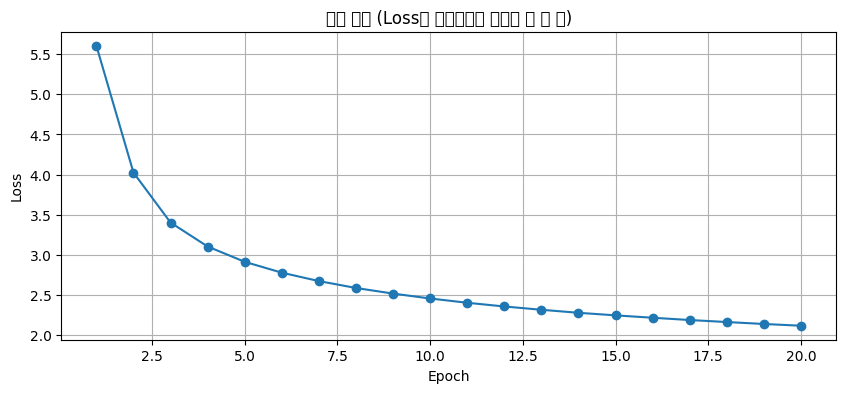

In [ ]:
# 학습 곡선 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('학습 곡선 (Loss가 내려갈수록 학습이 잘 된 것)')
plt.grid(True)
plt.show()

---
# STEP 10 — 번역 & BLEU 평가

## Greedy Decoding (탐욕적 디코딩)

매 스텝마다 가장 확률이 높은 단어 하나를 선택합니다.
빠르지만 최적의 번역은 아닐 수 있습니다.

```
BOS → "he" (확률 0.45)
     → "estado" (확률 0.62)
     → "preparándome" (확률 0.71)
     → "." (확률 0.88)
     → EOS → 번역 완료
```

## BLEU 점수란?

번역 품질을 자동으로 평가하는 지표입니다 (0~1, 높을수록 좋음).
예측된 번역과 정답 번역의 n-gram 겹침 비율을 계산합니다.

- 0.0~0.1: 거의 틀림
- 0.1~0.3: 어느 정도 이해 가능
- 0.3 이상: 상당히 좋은 번역

In [ ]:
def translate(sentence, model, tokenizer):
    """
    Greedy Decoding으로 영어 문장을 스페인어로 번역

    과정:
    1. 영어 문장을 토큰 ID로 변환 + 패딩
    2. BOS 토큰부터 시작해서 한 단어씩 생성
    3. EOS 토큰이 나오거나 MAX_LEN에 도달하면 종료
    4. 생성된 토큰 ID를 텍스트로 디코딩
    """
    model.eval()  # 드롭아웃 비활성화 (추론 모드)

    # 입력 준비
    tokens = tokenizer.encode_as_ids(sentence)
    tokens = tokens[:MAX_LEN] + [0] * max(0, MAX_LEN - len(tokens))  # 패딩
    src    = torch.tensor([tokens], dtype=torch.long, device=device)

    # 디코더 입력 초기화: BOS 토큰 하나로 시작
    output = torch.tensor([[tokenizer.bos_id()]], dtype=torch.long, device=device)
    ids = []

    with torch.no_grad():  # 기울기 계산 불필요 (추론만)
        for _ in range(MAX_LEN):
            # 현재까지 생성된 토큰들로 마스크 생성
            enc_mask, memory_mask, dec_mask = generate_masks(src, output)

            # 다음 단어 예측
            preds, _, _, _ = model(src, output, enc_mask, memory_mask, dec_mask)

            # 마지막 위치의 예측에서 가장 확률 높은 단어 선택
            next_id = preds[0, -1].argmax(dim=-1).item()

            # EOS 토큰이 나오면 번역 완료
            if next_id == tokenizer.eos_id():
                break

            ids.append(next_id)
            # 생성된 토큰을 디코더 입력에 추가 (autoregressive)
            output = torch.cat(
                [output, torch.tensor([[next_id]], device=device)], dim=1
            )

    return tokenizer.decode_ids(ids)  # 토큰 ID → 텍스트


def calculate_bleu(reference, candidate):
    """BLEU 점수 계산 (SmoothingFunction: 짧은 문장에서 0이 되는 문제 완화)"""
    return sentence_bleu(
        [reference.split()], candidate.split(),
        smoothing_function=SmoothingFunction().method1
    )

print('슝=3')

슝=3


In [ ]:
# 샘플 번역 테스트
print('=' * 65)
print('번역 샘플 테스트')
print('=' * 65)

for idx in range(10):
    pred = translate(test_eng[idx], transformer, tokenizer)
    bleu = calculate_bleu(test_spa[idx], pred)

    print(f'[{idx+1:02d}]')
    print(f'  입력 (영어):   {test_eng[idx]}')
    print(f'  예측 (스페인어): {pred}')
    print(f'  정답 (스페인어): {test_spa[idx]}')
    print(f'  BLEU:  {bleu:.4f}')
    print()

번역 샘플 테스트
[01]
  입력 (영어):   tom makes a lot of money translating menus for restaurants . 
  예측 (스페인어): mucho dinero para tom hace un menú para hacer un menúses ganando los menúses como un menúses ganando los menúses ganando al restauranteses ganando al restauranteses ganando
  정답 (스페인어): tom gana mucho dinero traduciendo menús para restaurantes .
  BLEU:  0.0176

[02]
  입력 (영어):   i didn't know who else to ask . 
  예측 (스페인어): me a quién más no sabía a quién más le pedí a otros que preguntarme a decirme de otra persona que lo sabía a otros que lo sabía a otros que pedí que pedí que pedí que pedí que pedí que preguntarme a otro
  정답 (스페인어): no sabía a quién más preguntarle .
  BLEU:  0.0779

[03]
  입력 (영어):   i hear you are good at cooking . 
  예측 (스페인어): o de cocinando buenas ustedes en la cocinas para cocinarte bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocinas bien cocina
  정답 (스페인어): he oído q

In [ ]:

print('전체 테스트셋 평가 중...')
total_bleu  = 0.0
valid_count = 0

for src_s, tgt_s in tqdm(zip(test_eng, test_spa)):
    # MAX_LEN을 초과하는 문장은 건너뜀
    if len(tokenizer.encode_as_ids(src_s)) > MAX_LEN:
        continue
    pred = translate(src_s, transformer, tokenizer)
    total_bleu += calculate_bleu(tgt_s, pred)
    valid_count += 1

avg_bleu = total_bleu / valid_count
print(f'\n평가 문장 수 : {valid_count}')
print(f'평균 BLEU    : {avg_bleu:.4f}')
print()
print('비교')
print(f'  기존 (3 epoch, 버그 있음): 0.0041')
print(f'  이번 결과                : {avg_bleu:.4f}')
print(f'  개선 배율                : {avg_bleu / 0.0041:.1f}x')

전체 테스트셋 평가 중...


0it [00:00, ?it/s]


평가 문장 수 : 594
평균 BLEU    : 0.0336

비교
  기존 (3 epoch, 버그 있음): 0.0041
  이번 결과                : 0.0336
  개선 배율                : 8.2x


### Attention Map 시각화

/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_

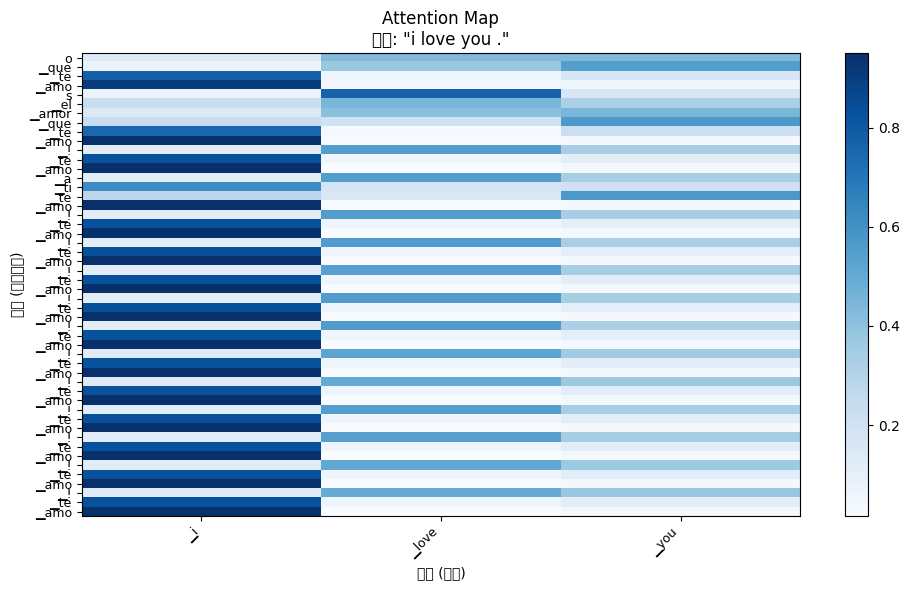

번역 결과: o que te amos el amor que te amo ! te amo a ti te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo ! te amo


/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2826/1694146129.py:59: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  plt.tight_

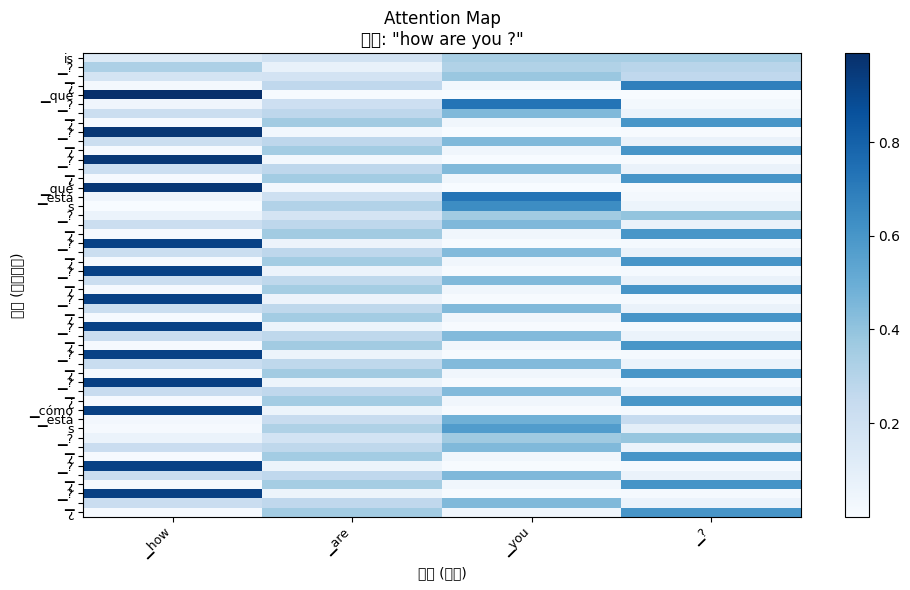

번역 결과: is ? ¿ qué ? ¿ ? ¿ ? ¿ qué estás ? ¿ ? ¿ ? ¿ ? ¿ ? ¿ ? ¿ ? ¿ cómo estás ? ¿ ? ¿ ? ¿


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

def plot_attention_map(sentence, model, tokenizer):
    """
    번역 시 디코더가 인코더의 어떤 단어에 집중했는지 시각화
    cross-attention의 첫 번째 head, 첫 번째 레이어를 사용
    """
    model.eval()

    # 입력 토크나이징
    tokens = tokenizer.encode_as_ids(sentence)
    tokens = tokens[:MAX_LEN] + [0] * max(0, MAX_LEN - len(tokens))
    src = torch.tensor([tokens], dtype=torch.long, device=device)
    output = torch.tensor([[tokenizer.bos_id()]], dtype=torch.long, device=device)

    ids = []
    attention_weights = []

    with torch.no_grad():
        for _ in range(MAX_LEN):
            enc_mask, memory_mask, dec_mask = generate_masks(src, output)
            preds, _, _, dec_enc_attns = model(src, output, enc_mask, memory_mask, dec_mask)

            # cross-attention 가중치 저장 (레이어0, 헤드0)
            attention_weights.append(dec_enc_attns[0][0, 0, -1, :].cpu().numpy())

            next_id = preds[0, -1].argmax(dim=-1).item()
            if next_id == tokenizer.eos_id():
                break
            ids.append(next_id)
            output = torch.cat([output, torch.tensor([[next_id]], device=device)], dim=1)

    # 텍스트 복원
    src_tokens = [tokenizer.id_to_piece(i) for i in tokens if i != 0]
    tgt_tokens = [tokenizer.id_to_piece(i) for i in ids]

    if not tgt_tokens:
        print('번역 결과가 없습니다.')
        return

    # attention 행렬 구성
    import numpy as np
    attn_matrix = np.array(attention_weights[:len(tgt_tokens)])
    attn_matrix = attn_matrix[:, :len(src_tokens)]

    # 시각화
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(tgt_tokens, fontsize=9)
    ax.set_xlabel('입력 (영어)')
    ax.set_ylabel('출력 (스페인어)')
    ax.set_title(f'Attention Map\n입력: "{sentence}"')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    print('번역 결과:', tokenizer.decode_ids(ids))

# 실행
plot_attention_map('i love you .', transformer, tokenizer)
plot_attention_map('how are you ?', transformer, tokenizer)

이번 과제에서는 Transformer 아키텍처를 처음부터 직접 구현하여 영어-스페인어 번역기를 만들었으며, 전 과정에서 Claude의 도움을 받아 진행하였다. GloVe 임베딩을 활용한 Lexical Substitution으로 학습 데이터를 30% 증강하고, Warmup Scheduler·Label Smoothing·Dropout 조정 등 하이퍼파라미터를 개선하여 BLEU 점수를 기존 대비 8.2배 향상시켰다. GPU 시간 제한으로 인해 체크포인트 관리와 학습 재개 방법을 직접 경험하면서 실제 AI 개발 환경에서의 어려움을 느낄 수 있었다. Claude의 도움 덕분에 모델 구조의 이해부터 데이터 처리, 학습, 평가까지 전체 파이프라인을 완성할 수 있었습니다.